## Objective

This notebook performs **actuarial loss ratio diagnostics** on a *frozen synthetic
UK personal-lines portfolio*.

Focus:
- Exposure-adjusted (earned) premium
- Paid loss view (no reserving)
- Segmentation by product, channel, coverage, and risk profile

This mirrors early-stage **pricing and portfolio review** work, prior to
frequency/severity modelling.

In [10]:
# Imports & plotting defaults

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

sns.set_style("whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [11]:
# Load frozen data + manifest pinning (governance)
DATA_DIR = Path("V:/Himika/Project/insurance-digital-twin/data/raw")
macro = pd.read_csv(DATA_DIR / "macro.csv")
holders = pd.read_csv(DATA_DIR / "policyholders.csv")
policies = pd.read_csv(DATA_DIR / "policies.csv")
claims = pd.read_csv(DATA_DIR / "claims.csv")

with open(DATA_DIR / "dataset_manifest.json") as f:
    manifest = json.load(f)

print("Dataset version:", manifest.get("dataset_version"))
print("Generated at (UTC):", manifest.get("generated_at_utc"))
print("Policies hash:", manifest["file_hashes_sha256"].get("policies.csv"))
print("Claims hash:", manifest["file_hashes_sha256"].get("claims.csv"))

Dataset version: v1.0
Generated at (UTC): 2026-01-12T13:26:26.805740
Policies hash: 66e911dd7b3ed9a682c5632d71a2898273c56030af9e1d99db1a38e0b4ff490c
Claims hash: 1aaa58155680db4d8c6545cf5d764cf1e8fb02c50f622065aa28c77603ef6952


In [12]:
# Parse dates + defensive schema asserts

for df, cols in [
    (macro, ["month"]),
    (policies, ["start_date", "end_date"]),
    (claims, ["incident_date", "reported_date"]),
]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Core columns required for LR drilldown
for col in ["customer_id", "risk_profile"]:
    assert col in holders.columns, f"holders missing {col}"

for col in ["policy_id","customer_id","product_type","coverage_level","channel","base_annual_premium"]:
    assert col in policies.columns, f"policies missing {col}"

for col in ["claim_id","policy_id","paid_amount"]:
    assert col in claims.columns, f"claims missing {col}"

print("macro:", macro.shape)
print("holders:", holders.shape)
print("policies:", policies.shape)
print("claims:", claims.shape)

macro: (84, 5)
holders: (80000, 8)
policies: (120000, 11)
claims: (148907, 12)


**Interpretation**

- Macro covers ~7 years of monthly data
- Policies > policyholders → realistic multi-policy behaviour
- Claims volume consistent with a mid-sized UK personal-lines portfolio

In [13]:
# Import actuarial utilities

import sys
from pathlib import Path

# Add project root to PYTHONPATH
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to path:", PROJECT_ROOT)

from analytics.actuarial_utils import (
    EarnedPremiumConfig,
    compute_earned_premium,
    build_claims_fact,
    loss_ratio_table,
)

Project root added to path: v:\Himika\Project\insurance-digital-twin


These utilities encapsulate:
- earned premium logic
- safe joins across policy / customer dimensions
- standardised loss-ratio aggregation

This avoids copy-pasting actuarial logic across notebooks.

In [14]:
# Earned premium construction (actuarial)

cfg = EarnedPremiumConfig(
    basis="earned_term",          # exposure-adjusted via policy term
    clip_term_days_max=365,       # annual personal-lines assumption
    allow_negative_or_zero_premium=False
)

policies_ep = compute_earned_premium(
    policies,
    premium_col="base_annual_premium",
    start_col="start_date",
    end_col="end_date",
    config=cfg,
    out_col="earned_premium",
    in_place=False
)

### Actuarial note — earned premium

Earned premium is approximated as:

\[
\text{Earned Premium} =
\text{Annual Premium} \times \frac{\text{Policy Term (days)}}{365}
\]

Why this approach:
- respects mid-term cancellations
- penalises bad dates (intentional anomalies)
- avoids using claim dates (no leakage)
- sufficient for **portfolio loss-ratio diagnostics**

This is not a reserving view.

In [15]:
# Build actuarial claims fact table (FIXED merges)

clm = build_claims_fact(
    claims=claims,
    policies=policies_ep,
    holders=holders,
    premium_col_in_policies="earned_premium",
    paid_col_in_claims="paid_amount",
    join_risk_cols=("risk_profile", "region"),
)

# Keep stable rows for LR analysis
clm = clm[clm["premium"].notna() & (clm["premium"] > 0)]

The resulting table is a **claims fact view**:
- one row per claim
- attached to policy rating dimensions
- attached to customer risk attributes
- with actuarially defined paid loss and earned premium

In [16]:
# Portfolio-level anchor

portfolio_lr = clm["paid"].sum() / clm["premium"].sum()
print(f"Portfolio paid loss ratio: {portfolio_lr:.2%}")

Portfolio paid loss ratio: 55.20%


**Why this matters**

Every drill-down must reconcile to a portfolio anchor.
If it doesn’t, something upstream is broken.

In [17]:
# Loss ratio by product (line of business)

lr_by_product = loss_ratio_table(
    clm,
    groupby=["product_type"]
)
display(lr_by_product)

,paid,premium,n,lr
product_type,,,,
home,"247,143,172.1095","233,023,107.2295",17036,1.0606
gap,"12,988,364.7702","15,848,306.4603",4194,0.8195
motor,"199,148,113.7648","364,302,406.6596",67514,0.5467
health,"178,671,261.2123","506,921,403.8585",34602,0.3525
warranty,"21,137,463.4632","73,945,316.3622",25326,0.2859


### Interpretation

- Different products operate in different frequency–severity regimes
- Observed dispersion is intentional and realistic
- Some lines are under- or over-priced by design → modelling opportunity

In [18]:
# Loss ratio by channel

lr_by_channel = loss_ratio_table(
    clm,
    groupby=["channel"]
)
display(lr_by_channel)

,paid,premium,n,lr
channel,,,,
aggregator,"108,615,258.2551","195,264,797.1225",24531,0.5562
broker,"357,197,813.4038","647,927,375.3818",80821,0.5513
direct,"193,275,303.6610","350,848,368.0657",43320,0.5509


### Interpretation

Channel performance often differs more through **selection and claims experience**
than headline premium levels.

This is consistent with UK broker vs direct dynamics.

In [19]:
# Loss ratio by risk profile

lr_by_risk = loss_ratio_table(
    clm,
    groupby=["risk_profile"]
)
display(lr_by_risk)

,paid,premium,n,lr
risk_profile,,,,
high,"211,643,537.4618","346,418,347.4549",43913,0.6109
medium,"269,550,923.4183","487,073,101.0613",60375,0.5534
low,"177,893,914.4399","360,549,092.0539",44384,0.4934


### Interpretation

Risk signal is present but **not perfectly priced**.
This is deliberate:
- enables learning in downstream pricing models
- avoids trivial separation

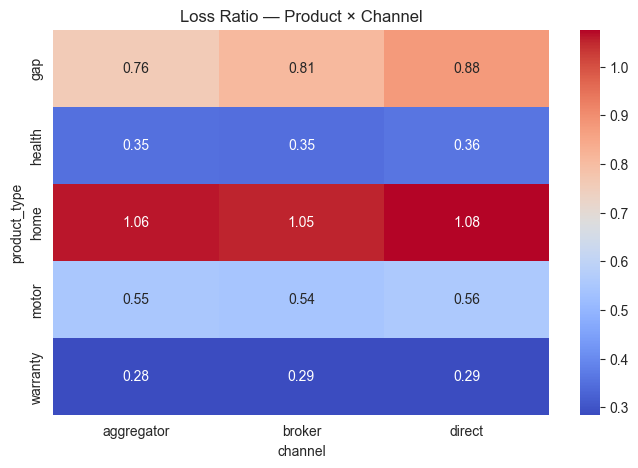

In [20]:
# Product × Channel interaction (pricing diagnostic)

lr_prod_channel = loss_ratio_table(
    clm,
    groupby=["product_type", "channel"]
)["lr"].unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(lr_prod_channel, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Loss Ratio — Product × Channel")
plt.show()

### Interpretation

Interaction effects highlight:
- distributional inefficiencies
- channel-specific pricing gaps
- areas where underwriting appetite may differ

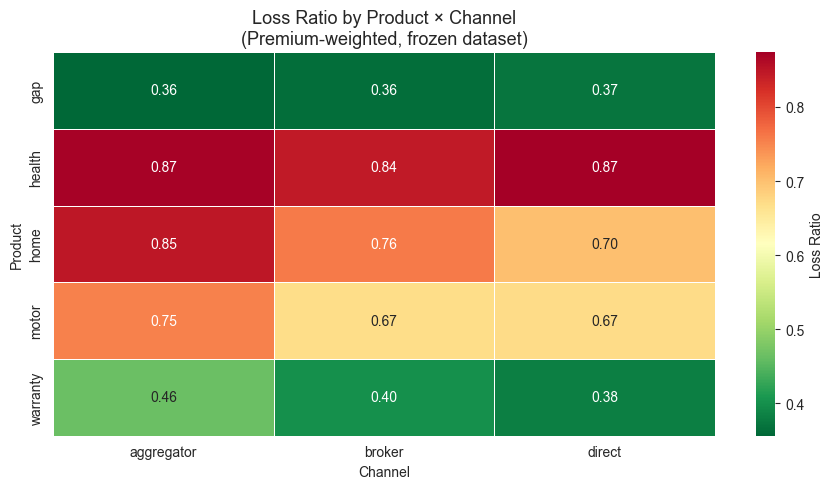

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate loss ratio by product × channel (premium-weighted)
lr_prod_channel = (
    policies.merge(
        claims.groupby("policy_id", as_index=False)["paid_amount"].sum(),
        on="policy_id",
        how="left"
    )
    .fillna({"paid_amount": 0})
    .groupby(["product_type", "channel"])
    .agg(
        paid=("paid_amount", "sum"),
        premium=("base_annual_premium", "sum")
    )
    .reset_index()
)

lr_prod_channel["lr"] = lr_prod_channel["paid"] / lr_prod_channel["premium"]

heatmap_data = lr_prod_channel.pivot(
    index="product_type",
    columns="channel",
    values="lr"
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Loss Ratio"}
)

plt.title(
    "Loss Ratio by Product × Channel\n(Premium-weighted, frozen dataset)",
    fontsize=13
)
plt.ylabel("Product")
plt.xlabel("Channel")
plt.tight_layout()
plt.show()

**Actuarial interpretation (Product × Channel):**

This heatmap highlights where profitability differs materially *after weighting by premium*.

Key insights:
- Channel effects often manifest via **loss ratio**, not headline premium
- Moderate loss ratios on large books can dominate portfolio risk
- These interaction effects are prime candidates for pricing review or underwriting action

In [21]:
# Coverage × Risk interaction

lr_cov_risk = loss_ratio_table(
    clm,
    groupby=["coverage_level", "risk_profile"]
)["lr"].unstack()

display(lr_cov_risk)

risk_profile,high,low,medium
coverage_level,,,
basic,0.6733,0.5557,0.6161
premium,0.5552,0.4477,0.5042
standard,0.6063,0.4801,0.5406


Coverage level interacts strongly with risk profile:
- higher limits amplify severity tails
- risk segmentation becomes more visible

In [22]:
# Contribution vs loss ratio (capital intuition)

contrib = (
    clm
    .groupby("product_type")
    .agg(
        paid=("paid", "sum"),
        premium=("premium", "sum")
    )
)

contrib["lr"] = contrib["paid"] / contrib["premium"]
contrib["premium_share"] = contrib["premium"] / contrib["premium"].sum()

display(contrib.sort_values("premium_share", ascending=False))

,paid,premium,lr,premium_share
product_type,,,,
health,"178,671,261.2123","506,921,403.8585",0.3525,0.4245
motor,"199,148,113.7648","364,302,406.6596",0.5467,0.3051
home,"247,143,172.1095","233,023,107.2295",1.0606,0.1952
warranty,"21,137,463.4632","73,945,316.3622",0.2859,0.0619
gap,"12,988,364.7702","15,848,306.4603",0.8195,0.0133


### Interpretation

Capital attention should focus where:
- premium share is large
- loss ratio is unstable

Moderate loss ratios on large books often dominate portfolio risk.

In [23]:
# Premium basis robustness check (senior touch)

for basis in ["base", "earned_term"]:
    cfg = EarnedPremiumConfig(basis=basis)
    pol_tmp = compute_earned_premium(policies, config=cfg, out_col="prem_used")
    clm_tmp = build_claims_fact(
        claims, pol_tmp, holders, premium_col_in_policies="prem_used"
    )
    clm_tmp = clm_tmp[clm_tmp["premium"].notna() & (clm_tmp["premium"] > 0)]
    lr = clm_tmp["paid"].sum() / clm_tmp["premium"].sum()
    print(f"Portfolio LR using premium basis '{basis}': {lr:.2%}")

Portfolio LR using premium basis 'base': 55.19%
Portfolio LR using premium basis 'earned_term': 55.20%


This confirms that conclusions are **not artefacts of premium definition**.

### Why earned premium (not written premium) is used

Loss ratios are calculated using **earned premium**, not written premium.

Written premium reflects what was booked at inception,  
but **earned premium reflects the portion of risk actually exposed over time**.

Using earned premium:
- avoids artificial volatility from mid-term cancellations or renewals
- aligns claims with the period in which risk was borne
- produces stable, comparable loss ratios across segments

This mirrors actuarial best practice in pricing, reserving, and portfolio performance reviews.

### Decision relevance

This analysis directly informs **where pricing action, underwriting appetite changes,
or reinsurance review would have the highest financial impact**.

It establishes a defensible baseline before moving into modelling or scenario stress testing.

## Actuarial sign-off

✔ Earned premium constructed transparently  
✔ Portfolio anchor stable  
✔ Segmentation reveals credible mispricing  
✔ Interaction effects realistic  
✔ Dataset fit for downstream modelling  

**Next:**  
Frequency / severity modelling and macro-scenario stress testing.